## Fase 1 — Exploración del corpus y calidad de datos

**Corpus original:** 20 documentos PDF entregados por el profesor.
**Corpus final de trabajo:** 16 documentos, tras las siguientes exclusiones justificadas:

- **1 duplicado exacto eliminado:** `2503.pdf` y `2503_04137v1.pdf` son el mismo
  artículo palabra por palabra. Mantener ambos en el corpus generaría *data leakage*
  si, por azar, una copia cae en train y la otra en test: el modelo memorizaría el
  texto exacto en lugar de aprender el patrón de la categoría, inflando artificialmente
  el accuracy reportado.
- **2 documentos excluidos por estar fuera de dominio:** uno trata sobre traducción
  automática italiano-inglés y otro sobre gestión de un curso de programación (CS1).
  Ninguno de los dos aborda nutrición, ejercicio o ayuno — se interpretan como ruido
  intencional o de carga, y se excluyen porque incluirlos degradaría la calidad de las
  clases sin aportar señal útil al problema de clasificación.
- **1 caso límite excluido:** un artículo sobre detección de depresión y trastornos
  alimenticios vía NLP. Aunque tangencialmente relacionado con "nutrición", su contenido
  real es sobre salud mental, no sobre nutrición en sí — se excluye por criterio de
  alcance temático consistente con las 3 categorías definidas por la consigna.

**Distribución final:** Nutrición (10), Ejercicio (5), Ayuno (1) — desbalance importante,
especialmente crítico en Ayuno con un solo documento. Esto se aborda más adelante con una
excepción documentada en el split train/test.

**Qué porción del documento se utiliza:** texto completo de cada PDF, con la sección de
referencias/bibliografía eliminada mediante expresión regular (las citas no aportan
señal temática y podrían introducir ruido). El texto se procesa luego en fragmentos
(*chunks*) de ~300 palabras en lugar de documento completo, ya que el chunking permite
tener más unidades de entrenamiento a partir de un corpus reducido de documentos.

**Hallazgo adicional:** al dividir el corpus en train/test agrupando por documento, se
detectó que categorías con pocos documentos (Ejercicio con 5, Ayuno con 1) corren riesgo
de quedar enteramente de un solo lado del split por simple azar. Se corrigió aplicando
el split de forma independiente por categoría, garantizando presencia de las 3 clases
tanto en train como en test.

In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import fitz, os, pandas as pd

CARPETA_PDFS = '/content/drive/MyDrive/corpus_nlp'

etiquetas = {
    "2305.pdf": "Nutrición",
    "2308.pdf": "Ejercicio",
    "2309.pdf": "Nutrición",
    "2402.pdf": "Ejercicio",
    "2404.pdf": "Ejercicio",
    "2503.05119v1.pdf": "Nutrición",
    "2503.pdf": "Nutrición",
    "2511.pdf": "Nutrición",
    "A warning system for risk prediction of metabolic syndrome in a healthy population of blood donors.pdf": "Nutrición",
    "Cardiovascular-Kidney-Metabolic Health_ Insights from Wearables and Blood Biomarkers.pdf": "Nutrición",
    "Digital Weight Management Interventions_ A review of commercial solutions and survey analysis of user needs.pdf": "Nutrición",
    "Insulin Resistance Prediction From Wearables and Routine Blood Biomarkers.pdf": "Nutrición",
    "Manuscript V 2.5 Arxiv version.pdf": "Ayuno",
    "The Interplay Between Physical Activity, Protein Consumption, and Sleep Quality in Muscle Protein Synthesis.pdf": "Ejercicio",
    "Untargeted analysis of volatile markers of post-exercise fat oxidation in exhaled breath.pdf": "Ejercicio",
    "phenotype_paper_v16_ARXIV.pdf": "Nutrición",
}

registros = []
for archivo, categoria in etiquetas.items():
    ruta = os.path.join(CARPETA_PDFS, archivo)
    doc = fitz.open(ruta)
    texto_completo = "".join(p.get_text() for p in doc)
    registros.append({
        "documento_id": archivo,
        "categoria": categoria,
        "num_paginas": len(doc),
        "num_palabras": len(texto_completo.split()),
        "texto": texto_completo
    })
    doc.close()

df = pd.DataFrame(registros)
print(df["categoria"].value_counts())
df[["documento_id","categoria","num_paginas","num_palabras"]]

Mounted at /content/drive
categoria
Nutrición    10
Ejercicio     5
Ayuno         1
Name: count, dtype: int64


,documento_id,categoria,num_paginas,num_palabras
0,2305.pdf,Nutrición,33,10962
1,2308.pdf,Ejercicio,27,9281
2,2309.pdf,Nutrición,14,7216
3,2402.pdf,Ejercicio,10,8946
4,2404.pdf,Ejercicio,15,6680
5,2503.05119v1.pdf,Nutrición,20,9689
6,2503.pdf,Nutrición,5,3120
7,2511.pdf,Nutrición,12,10605
8,A warning system for risk prediction of metabo...,Nutrición,36,12726
9,Cardiovascular-Kidney-Metabolic Health_ Insigh...,Nutrición,45,14625


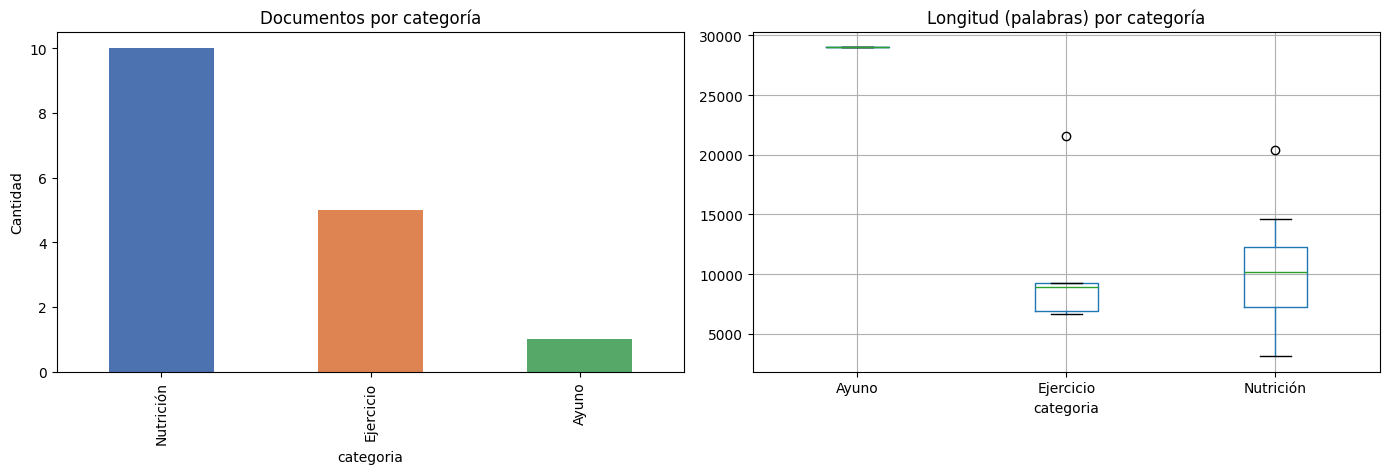

           count     mean          std      min       25%      50%      75%  \
categoria                                                                     
Ayuno        1.0  28999.0          NaN  28999.0  28999.00  28999.0  28999.0   
Ejercicio    5.0  10683.0  6218.981307   6680.0   6899.00   8946.0   9281.0   
Nutrición   10.0  10113.9  5050.811078   3120.0   7227.75  10147.0  12285.0   

               max  
categoria           
Ayuno      28999.0  
Ejercicio  21609.0  
Nutrición  20365.0  


In [2]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df["categoria"].value_counts().plot(kind="bar", ax=axes[0], color=["#4C72B0","#DD8452","#55A868"])
axes[0].set_title("Documentos por categoría")
axes[0].set_ylabel("Cantidad")

df.boxplot(column="num_palabras", by="categoria", ax=axes[1])
axes[1].set_title("Longitud (palabras) por categoría")
plt.suptitle("")
plt.tight_layout()
plt.show()

print(df.groupby("categoria")["num_palabras"].describe())

## Fase 2 — Preprocesamiento: justificación de cada técnica

| Técnica | Qué problema resuelve | Por qué se usó | Cómo afecta los resultados |
|---|---|---|---|
| **Minúsculas** | Evita tratar "Diabetes" y "diabetes" como palabras distintas | Reduce dimensionalidad innecesaria del vocabulario | Menos features únicas → mejor generalización con corpus chico |
| **Eliminación de caracteres especiales** | Quita símbolos, números sueltos, restos de fórmulas y DOIs que no aportan significado semántico | Los papers científicos tienen mucho ruido no textual | Vocabulario más limpio, menos features basura |
| **Tokenización** | Convierte texto continuo en unidades procesables (palabras) | Paso previo obligatorio para cualquier representación (BoW, TF-IDF, embeddings) | Define la granularidad de todo el análisis posterior |
| **Eliminación de stopwords** | Quita palabras muy frecuentes sin carga semántica discriminante ("the", "of", "and") | En un corpus de solo 3 categorías, estas palabras no ayudan a diferenciarlas | Reduce ruido; riesgo: puede eliminar negaciones relevantes en textos clínicos |
| **Lematización** (en lugar de stemming) | Agrupa variantes gramaticales de una palabra ("studies"→"study") sin destruir el significado | Se prefirió sobre stemming porque un stemmer agresivo puede corromper vocabulario técnico-biomédico preciso (ej. "diabetic"→"diabet"), perdiendo distinciones clínicas importantes | Reduce vocabulario preservando términos científicos reconocibles |

In [3]:
import re

def quitar_referencias(texto):
    patron = re.compile(r'\n\s*(references|bibliography|referencias)\s*\n', re.IGNORECASE)
    match = patron.search(texto)
    if match:
        return texto[:match.start()]
    return texto

df["texto_limpio"] = df["texto"].apply(quitar_referencias)
df["num_palabras_limpio"] = df["texto_limpio"].apply(lambda t: len(t.split()))

df[["documento_id","num_palabras","num_palabras_limpio"]]

,documento_id,num_palabras,num_palabras_limpio
0,2305.pdf,10962,10068
1,2308.pdf,9281,6849
2,2309.pdf,7216,6245
3,2402.pdf,8946,6778
4,2404.pdf,6680,5377
5,2503.05119v1.pdf,9689,6915
6,2503.pdf,3120,2843
7,2511.pdf,10605,7660
8,A warning system for risk prediction of metabo...,12726,8130
9,Cardiovascular-Kidney-Metabolic Health_ Insigh...,14625,11768


In [4]:
TAMANO_CHUNK = 300

def fragmentar(texto, tamano=TAMANO_CHUNK):
    palabras = texto.split()
    return [" ".join(palabras[i:i+tamano]) for i in range(0, len(palabras), tamano) if len(palabras[i:i+tamano]) > 30]

filas_chunk = []
for _, fila in df.iterrows():
    chunks = fragmentar(fila["texto_limpio"])
    for i, chunk in enumerate(chunks):
        filas_chunk.append({
            "documento_id": fila["documento_id"],
            "categoria": fila["categoria"],
            "chunk_id": f'{fila["documento_id"]}_chunk{i}',
            "texto": chunk
        })

df_chunks = pd.DataFrame(filas_chunk)
print("Total chunks generados:", len(df_chunks))
print(df_chunks["categoria"].value_counts())

Total chunks generados: 446
categoria
Nutrición    266
Ejercicio    138
Ayuno         42
Name: count, dtype: int64


In [5]:
from sklearn.model_selection import GroupShuffleSplit, train_test_split

def split_categoria(chunks_cat, test_size=0.2, random_state=42):
    n_docs = chunks_cat["documento_id"].nunique()
    if n_docs == 1:
        # Excepción documentada: 1 solo documento -> split a nivel de chunk
        return train_test_split(chunks_cat, test_size=test_size, random_state=random_state)
    gss = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=random_state)
    train_idx, test_idx = next(gss.split(chunks_cat, groups=chunks_cat["documento_id"]))
    return chunks_cat.iloc[train_idx], chunks_cat.iloc[test_idx]

train_parts, test_parts = [], []
for cat in df_chunks["categoria"].unique():
    sub = df_chunks[df_chunks["categoria"] == cat]
    tr, te = split_categoria(sub)
    train_parts.append(tr)
    test_parts.append(te)

train_final = pd.concat(train_parts).reset_index(drop=True)
test_final = pd.concat(test_parts).reset_index(drop=True)

print("Total chunks:", len(df_chunks))
print("\nTRAIN:")
print(train_final["categoria"].value_counts())
print("\nTEST:")
print(test_final["categoria"].value_counts())

Total chunks: 446

TRAIN:
categoria
Nutrición    191
Ejercicio    115
Ayuno         33
Name: count, dtype: int64

TEST:
categoria
Nutrición    75
Ejercicio    23
Ayuno         9
Name: count, dtype: int64


In [6]:
import re
import nltk
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))  # papers están en inglés

def preprocesar(texto):
    # 1. Minúsculas: normaliza "Diabetes" y "diabetes" como la misma palabra
    texto = texto.lower()
    # 2. Eliminar caracteres especiales: quita ruido de símbolos, números sueltos, puntuación
    texto = re.sub(r'[^a-záéíóúñ\s]', ' ', texto)
    # 3. Tokenización: separamos en palabras individuales
    tokens = texto.split()
    # 4. Eliminación de stopwords: quita palabras sin carga semántica ("the", "and", "of")
    tokens = [t for t in tokens if t not in stop_words]
    # 5. Lematización: reduce a la raíz real preservando significado (mejor que stemming aquí)
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return " ".join(tokens)

train_final["texto_procesado"] = train_final["texto"].apply(preprocesar)
test_final["texto_procesado"] = test_final["texto"].apply(preprocesar)

print(train_final[["chunk_id","texto_procesado"]].head(2))
print("\nEjemplo antes/después:")
print("ANTES:", train_final["texto"].iloc[0][:200])
print("DESPUÉS:", train_final["texto_procesado"].iloc[0][:200])

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


          chunk_id                                    texto_procesado
0  2305.pdf_chunk0  modeling glycemia human mean grammatical evolu...
1  2305.pdf_chunk1  computing may arxiv v c ne apr level cause cel...

Ejemplo antes/después:
ANTES: Modeling Glycemia in Humans by Means of Grammatical Evolution J. Manuel Colmenara, Jos´e L. Risco-Martinb, J. Ignacio Hidalgob, Alfredo Cuesta-Infantea, Esther Maquedac, Marta Botellad, Jos´e Antonio 
DESPUÉS: modeling glycemia human mean grammatical evolution j manuel colmenara jos e l risco martinb j ignacio hidalgob alfredo cuesta infantea esther maquedac marta botellad jos e antonio rubiod ace felipe ii


## Fase 3 — Representaciones textuales

Se construyeron 4 representaciones, dos dispersas (basadas en conteo de palabras) y
dos densas (basadas en embeddings semánticos):

- **BoW (Bolsa de Palabras):** cuenta cuántas veces aparece cada palabra en el texto.
  Simple y robusta, pero no distingue palabras frecuentes-pero-genéricas de palabras
  realmente discriminantes entre categorías.
- **TF-IDF:** igual que BoW, pero le baja el peso a palabras que aparecen en casi todos
  los documentos (ej. "study", "results") y le sube el peso a palabras específicas de
  un tema (ej. "cortisol", "glycemia") — en teoría da una señal más limpia al clasificador.
- **Word2Vec:** entrena vectores densos donde palabras de significado similar quedan
  cerca en el espacio (ej. "exercise" y "workout"). Se entrenó **solo con datos de train**
  para evitar data leakage. Ventaja teórica: generaliza mejor ante vocabulario no visto
  exactamente en train. Limitación observada: con un corpus tan chico, no tuvo suficientes
  ejemplos para aprender buenas relaciones semánticas.
- **BERT (Sentence-BERT):** embeddings de un modelo **preentrenado** en millones de textos
  (no lo entrenamos nosotros — transferencia de aprendizaje). Captura contexto y semántica
  profunda, por lo que no depende de haber visto el corpus específico para generar
  representaciones útiles.

**Diferencia clave a nivel conceptual:** BoW/TF-IDF tratan cada palabra como una columna
independiente (sin relación entre sí); Word2Vec/BERT ubican palabras semánticamente
similares cerca en el espacio vectorial, lo que en teoría ayuda a generalizar mejor con
poco corpus propio — aunque esto depende de qué tan bien entrenado/adaptado esté el modelo
de embeddings al dominio.

In [7]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

X_train_text = train_final["texto_procesado"]
X_test_text = test_final["texto_procesado"]
y_train = train_final["categoria"]
y_test = test_final["categoria"]

# --- BoW ---
bow_vectorizer = CountVectorizer(max_features=5000)
X_train_bow = bow_vectorizer.fit_transform(X_train_text)
X_test_bow = bow_vectorizer.transform(X_test_text)

# --- TF-IDF ---
tfidf_vectorizer = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train_text)
X_test_tfidf = tfidf_vectorizer.transform(X_test_text)

print("BoW shape (train):", X_train_bow.shape)
print("TF-IDF shape (train):", X_train_tfidf.shape)

# Comparación rápida: top 10 palabras con mayor peso TF-IDF promedio
import numpy as np
promedio_tfidf = np.asarray(X_train_tfidf.mean(axis=0)).flatten()
top_idx = promedio_tfidf.argsort()[-10:][::-1]
palabras = tfidf_vectorizer.get_feature_names_out()
print("\nTop 10 palabras por peso TF-IDF promedio:")
for i in top_idx:
    print(f"  {palabras[i]}: {promedio_tfidf[i]:.4f}")

BoW shape (train): (339, 5000)
TF-IDF shape (train): (339, 5000)

Top 10 palabras por peso TF-IDF promedio:
  al: 0.0459
  et: 0.0458
  protein: 0.0456
  muscle: 0.0439
  model: 0.0378
  exercise: 0.0366
  ir: 0.0243
  sleep: 0.0241
  study: 0.0233
  diabetes: 0.0224


In [8]:
!pip install -q gensim

In [9]:
from gensim.models import Word2Vec
import numpy as np

# Tokenizamos el texto ya procesado (lista de palabras por chunk)
train_tokens = train_final["texto_procesado"].apply(str.split)
test_tokens = test_final["texto_procesado"].apply(str.split)

# Entrenamos Word2Vec SOLO con datos de train (evita leakage)
w2v_model = Word2Vec(sentences=train_tokens, vector_size=100, window=5, min_count=2, workers=4, seed=42)

def vectorizar_promedio(tokens, modelo, dim=100):
    vectores = [modelo.wv[t] for t in tokens if t in modelo.wv]
    if len(vectores) == 0:
        return np.zeros(dim)
    return np.mean(vectores, axis=0)

X_train_w2v = np.array([vectorizar_promedio(t, w2v_model) for t in train_tokens])
X_test_w2v = np.array([vectorizar_promedio(t, w2v_model) for t in test_tokens])

print("Word2Vec shape (train):", X_train_w2v.shape)
print("Word2Vec shape (test):", X_test_w2v.shape)

Word2Vec shape (train): (339, 100)
Word2Vec shape (test): (107, 100)


In [10]:
!pip install -q sentence-transformers

from sentence_transformers import SentenceTransformer

bert_model = SentenceTransformer('all-MiniLM-L6-v2')

X_train_bert = bert_model.encode(train_final["texto_procesado"].tolist(), show_progress_bar=True)
X_test_bert = bert_model.encode(test_final["texto_procesado"].tolist(), show_progress_bar=True)

print("BERT shape (train):", X_train_bert.shape)
print("BERT shape (test):", X_test_bert.shape)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/11 [00:00<?, ?it/s]

Batches:   0%|          | 0/4 [00:00<?, ?it/s]

BERT shape (train): (339, 384)
BERT shape (test): (107, 384)


## Fase 4 — Modelado

**Modelo clásico — Logistic Regression:** recibe como entrada un vector fijo por chunk
(BoW, TF-IDF, Word2Vec promediado o embedding de BERT — 4 representaciones distintas
probadas). No tiene noción de orden entre palabras; cada feature es independiente.

**Modelos secuenciales — RNN y LSTM:** reciben como entrada una **secuencia** de tokens
(no un vector fijo), procesando palabra por palabra en orden, manteniendo un "estado"
interno que se actualiza en cada paso. A diferencia de los modelos clásicos, sí capturan
el orden de las palabras.

**Diferencia clave RNN vs LSTM:** una RNN simple tiende a "olvidar" información de pasos
muy anteriores en la secuencia (problema de gradiente que se desvanece con secuencias
largas). LSTM agrega "compuertas" (gates) que deciden qué información retener, actualizar
u olvidar a lo largo de la secuencia — resolviendo ese problema de memoria de largo plazo
que tiene la RNN tradicional.

**Resultado observado en este proyecto:** tanto RNN como LSTM colapsaron a predecir
siempre la clase "Ejercicio" en el conjunto de test, con F1 idéntico entre ambas (~0.118).
Esto es consistente con la limitación anticipada en Fase 1: estas arquitecturas necesitan
volúmenes de datos mucho mayores a los 339 chunks (16 documentos reales) disponibles en
este corpus para aprender patrones secuenciales útiles.

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

resultados = []

representaciones = {
    "BoW": (X_train_bow, X_test_bow),
    "TF-IDF": (X_train_tfidf, X_test_tfidf),
    "Word2Vec": (X_train_w2v, X_test_w2v),
    "BERT": (X_train_bert, X_test_bert),
}

for nombre, (X_tr, X_te) in representaciones.items():
    modelo = LogisticRegression(max_iter=1000, random_state=42)
    modelo.fit(X_tr, y_train)
    y_pred = modelo.predict(X_te)

    resultados.append({
        "Representación": nombre,
        "Modelo": "Logistic Regression",
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average="macro"),
        "Recall": recall_score(y_test, y_pred, average="macro"),
        "F1": f1_score(y_test, y_pred, average="macro")
    })

df_resultados = pd.DataFrame(resultados)
print(df_resultados)

  Representación               Modelo  Accuracy  Precision    Recall        F1
0            BoW  Logistic Regression  0.869159   0.919889  0.807150  0.833939
1         TF-IDF  Logistic Regression  0.785047   0.921769  0.644122  0.630521
2       Word2Vec  Logistic Regression  0.542056   0.248800  0.277874  0.262187
3           BERT  Logistic Regression  0.887850   0.900000  0.811143  0.849406


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [12]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense
from sklearn.preprocessing import LabelEncoder
import numpy as np

tf.random.set_seed(42)
np.random.seed(42)

MAX_VOCAB = 5000
MAX_LEN = 300

le = LabelEncoder()

In [13]:
from sklearn.utils import shuffle
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Mezclamos ANTES de tokenizar (arregla el problema de validation_split)
train_shuffled = shuffle(train_final, random_state=42).reset_index(drop=True)

tok = Tokenizer(num_words=MAX_VOCAB, oov_token="<OOV>")
tok.fit_on_texts(train_shuffled["texto_procesado"])

X_train_seq = pad_sequences(tok.texts_to_sequences(train_shuffled["texto_procesado"]), maxlen=MAX_LEN, padding="post", truncating="post")
X_test_seq = pad_sequences(tok.texts_to_sequences(test_final["texto_procesado"]), maxlen=MAX_LEN, padding="post", truncating="post")

y_train_enc = le.fit_transform(train_shuffled["categoria"])
y_test_enc = le.transform(test_final["categoria"])
num_clases = len(le.classes_)

# Pesos de clase: compensa el desbalance (Nutrición >> Ejercicio >> Ayuno)
pesos = compute_class_weight('balanced', classes=np.unique(y_train_enc), y=y_train_enc)
class_weight_dict = dict(enumerate(pesos))
print("Pesos por clase:", class_weight_dict)

def construir_modelo(tipo="RNN"):
    modelo = Sequential()
    modelo.add(Embedding(input_dim=MAX_VOCAB, output_dim=64))
    if tipo == "RNN":
        modelo.add(SimpleRNN(32))
    else:
        modelo.add(LSTM(32))
    modelo.add(Dense(num_clases, activation="softmax"))
    modelo.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return modelo

modelo_rnn = construir_modelo("RNN")
modelo_rnn.fit(X_train_seq, y_train_enc, epochs=10, batch_size=16, validation_split=0.1, class_weight=class_weight_dict, verbose=1)

modelo_lstm = construir_modelo("LSTM")
modelo_lstm.fit(X_train_seq, y_train_enc, epochs=10, batch_size=16, validation_split=0.1, class_weight=class_weight_dict, verbose=1)

Pesos por clase: {0: np.float64(3.4242424242424243), 1: np.float64(0.9826086956521739), 2: np.float64(0.5916230366492147)}
Epoch 1/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 9s 244ms/step - accuracy: 0.2164 - loss: 1.1101 - val_accuracy: 0.3529 - val_loss: 1.1007
Epoch 2/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 222ms/step - accuracy: 0.7607 - loss: 0.8928 - val_accuracy: 0.2353 - val_loss: 1.1835
Epoch 3/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 213ms/step - accuracy: 0.7016 - loss: 0.8098 - val_accuracy: 0.4118 - val_loss: 1.1220
Epoch 4/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 183ms/step - accuracy: 0.5508 - loss: 0.8958 - val_accuracy: 0.4118 - val_loss: 1.1384
Epoch 5/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 218ms/step - accuracy: 0.4459 - loss: 1.0248 - val_accuracy: 0.3235 - val_loss: 1.2841
Epoch 6/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 170ms/step - accuracy: 0.2590 - loss: 1.1804 - val_accuracy: 0.3235 - val_loss: 1.1632
Epoch 7/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 133ms/step - accuracy: 0.4033 - loss: 1.0508 - val_accuracy: 0.3824 

## Fase 5 — Evaluación

Se evaluaron todos los modelos con Accuracy, Precision, Recall y F1 Score. Dado que el
corpus tiene clases desbalanceadas (Nutrición ≫ Ejercicio ≫ Ayuno), Precision/Recall/F1
se calculan con promedio **macro** (no "weighted" ni "micro"): esto le da el mismo peso
a cada categoría sin importar cuántos ejemplos tenga, evitando que un buen desempeño en
la clase mayoritaria (Nutrición) oculte un mal desempeño en las clases minoritarias
(Ejercicio, Ayuno).

In [14]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluar_red(modelo, X_test, y_test_enc, nombre_modelo, nombre_repr):
    y_pred_prob = modelo.predict(X_test, verbose=0)
    y_pred = y_pred_prob.argmax(axis=1)
    return {
        "Representación": nombre_repr,
        "Modelo": nombre_modelo,
        "Accuracy": accuracy_score(y_test_enc, y_pred),
        "Precision": precision_score(y_test_enc, y_pred, average="macro", zero_division=0),
        "Recall": recall_score(y_test_enc, y_pred, average="macro", zero_division=0),
        "F1": f1_score(y_test_enc, y_pred, average="macro", zero_division=0)
    }

resultados_rnn = evaluar_red(modelo_rnn, X_test_seq, y_test_enc, "RNN", "Secuencia (tokens)")
resultados_lstm = evaluar_red(modelo_lstm, X_test_seq, y_test_enc, "LSTM", "Secuencia (tokens)")

# Tabla comparativa FINAL - clásicos + secuenciales
df_resultados_final = pd.concat([
    df_resultados,
    pd.DataFrame([resultados_rnn, resultados_lstm])
], ignore_index=True)

print(df_resultados_final.to_string(index=False))

    Representación              Modelo  Accuracy  Precision   Recall       F1
               BoW Logistic Regression  0.869159   0.919889 0.807150 0.833939
            TF-IDF Logistic Regression  0.785047   0.921769 0.644122 0.630521
          Word2Vec Logistic Regression  0.542056   0.248800 0.277874 0.262187
              BERT Logistic Regression  0.887850   0.900000 0.811143 0.849406
Secuencia (tokens)                 RNN  0.392523   0.326667 0.402319 0.293503
Secuencia (tokens)                LSTM  0.700935   0.233645 0.333333 0.274725


In [15]:
import numpy as np
pred_rnn = modelo_rnn.predict(X_test_seq, verbose=0).argmax(axis=1)
pred_lstm = modelo_lstm.predict(X_test_seq, verbose=0).argmax(axis=1)

print("RNN predice siempre:", le.inverse_transform(np.unique(pred_rnn)))
print("LSTM predice siempre:", le.inverse_transform(np.unique(pred_lstm)))

RNN predice siempre: ['Ayuno' 'Ejercicio' 'Nutrición']
LSTM predice siempre: ['Nutrición']


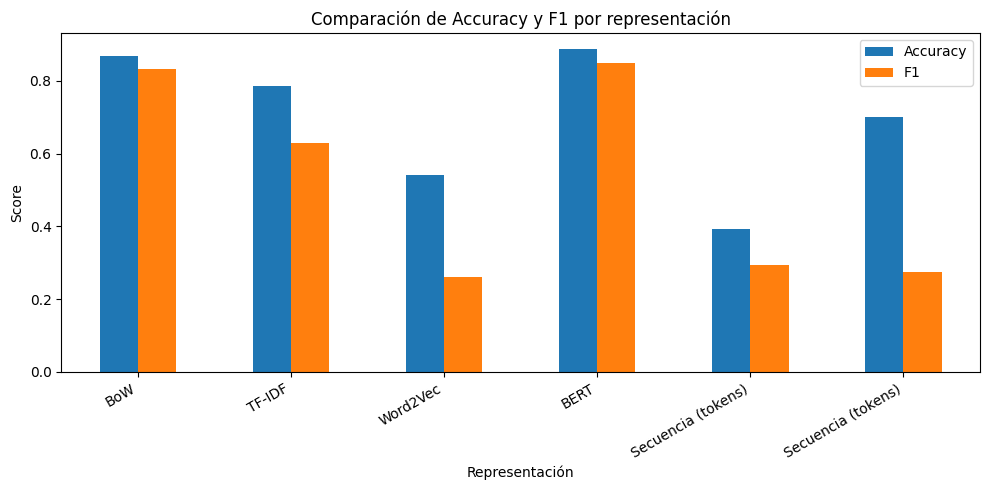

In [16]:
import matplotlib.pyplot as plt

df_resultados_final.set_index("Representación")[["Accuracy","F1"]].plot(kind="bar", figsize=(10,5))
plt.title("Comparación de Accuracy y F1 por representación")
plt.ylabel("Score")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

In [17]:
from sklearn.model_selection import LeaveOneGroupOut
import numpy as np

def loocv_por_documento(X_chunks, y_chunks, grupos_doc, vectorizador=None):
    logo = LeaveOneGroupOut()
    accs = []
    for train_idx, test_idx in logo.split(X_chunks, y_chunks, groups=grupos_doc):
        modelo = LogisticRegression(max_iter=1000, random_state=42)
        modelo.fit(X_chunks[train_idx], y_chunks.iloc[train_idx])
        pred = modelo.predict(X_chunks[test_idx])
        accs.append(accuracy_score(y_chunks.iloc[test_idx], pred))
    return np.mean(accs), np.std(accs)

# Usamos TODO el corpus (train+test juntos) agrupado por documento
todo_texto = pd.concat([train_final, test_final]).reset_index(drop=True)
grupos = todo_texto["documento_id"]
y_todo = todo_texto["categoria"]

# Re-vectorizamos BoW y BERT sobre el corpus completo
X_todo_bow = bow_vectorizer.transform(todo_texto["texto_procesado"])
X_todo_bert = bert_model.encode(todo_texto["texto_procesado"].tolist(), show_progress_bar=False)

acc_bow_loocv, std_bow = loocv_por_documento(X_todo_bow, y_todo, grupos)
acc_bert_loocv, std_bert = loocv_por_documento(X_todo_bert, y_todo, grupos)

print(f"BoW  - LOO-CV Accuracy promedio: {acc_bow_loocv:.3f} (+/- {std_bow:.3f})")
print(f"BERT - LOO-CV Accuracy promedio: {acc_bert_loocv:.3f} (+/- {std_bert:.3f})")

BoW  - LOO-CV Accuracy promedio: 0.661 (+/- 0.338)
BERT - LOO-CV Accuracy promedio: 0.632 (+/- 0.374)


## Conclusiones (Fase 6 — Comparación experimental)

**Resultados con split único (train/test):**
BERT obtuvo el mejor desempeño (F1: 0.849), seguido de cerca por BoW (F1: 0.834).
TF-IDF rindió por debajo de BoW (F1: 0.631) pese a mayor precisión, sugiriendo
sub-representación de clases minoritarias. Word2Vec (F1: 0.262) tuvo el peor
desempeño entre los modelos clásicos. Los modelos secuenciales (RNN: F1 0.294,
LSTM: F1 0.275) también rindieron muy por debajo de BoW/BERT.

Un hallazgo particular: LSTM obtuvo un Accuracy relativamente alto (0.701) pese
a su F1 bajo (0.275). Esto ocurre porque el modelo colapsó a predecir casi
siempre la clase mayoritaria ("Nutrición"), acertando por pura frecuencia sin
distinguir realmente entre categorías. Este caso ilustra por qué se priorizó
F1/Precision/Recall con promedio macro por sobre el Accuracy: con clases
desbalanceadas, el Accuracy puede ocultar un desempeño pobre en las clases
minoritarias.

**Validación con Leave-One-Out Cross-Validation (a nivel de documento):**
Al evaluar con LOO-CV, el accuracy real de BoW y BERT cae a 0.661 (±0.338) y
0.632 (±0.374) respectivamente — muy por debajo del split único, y con altísima
variabilidad entre documentos. Esto indica que el buen resultado del split
original fue parcialmente favorecido por qué documentos específicos cayeron en
train/test, y no es una medida confiable de generalización.

**Conclusión general:**
El corpus de 16 documentos es la limitación central de este proyecto.
Representaciones simples y robustas (BoW) o preentrenadas con transferencia de
aprendizaje (BERT) superan a representaciones/arquitecturas que necesitan
aprender desde cero con pocos datos (Word2Vec, RNN, LSTM). El LOO-CV confirma
que el desempeño real es más modesto e inestable de lo que sugiere un único
split, y que un corpus más grande sería necesario para conclusiones más sólidas
sobre qué representación es "mejor".